In [82]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Dense

class ExternalAttention(Layer):
    def __init__(self, units):
        super(ExternalAttention, self).__init__()
        self.units = units

    def build(self, input_shape):
        self.Wk = self.add_weight(shape=(input_shape[-1], self.units),
                                  initializer='glorot_uniform',
                                  trainable=True)
        self.Wv = self.add_weight(shape=(self.units, input_shape[-1]),
                                  initializer='glorot_uniform',
                                  trainable=True)

    def call(self, inputs):
        attention_scores = tf.matmul(inputs, self.Wk)
        attention_scores = tf.nn.softmax(attention_scores, axis=1)
        attention_output = tf.matmul(attention_scores, self.Wv)
        return attention_output + inputs


In [83]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

def create_external_attention_model(input_shape, num_classes,
                                     dense_units1, dense_units2,
                                     dropout_rate, l2_reg, learning_rate):
    model = Sequential([
        Input(shape=(input_shape,)),
        Dense(dense_units1, activation='relu', kernel_regularizer=l2(l2_reg)),
        BatchNormalization(),
        Dropout(dropout_rate),
        ExternalAttention(128),
        Dense(dense_units2, activation='relu', kernel_regularizer=l2(l2_reg)),
        Dropout(dropout_rate),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model


In [84]:
import pandas as pd
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Load data
X = pd.read_csv("combined_features.csv").values
y = pd.read_csv("labels_one_hot_encoded.csv").values
y_raw = np.argmax(y, axis=1)

# Compute class weights
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_raw), y=y_raw)
class_weights = dict(enumerate(class_weights))


In [85]:
# Tuning configurations
param_grid = [
    {'lr': 0.001, 'l2': 0.001, 'dropout': 0.4, 'units1': 256, 'units2': 128},
    {'lr': 0.0005, 'l2': 0.001, 'dropout': 0.3, 'units1': 256, 'units2': 128},
    {'lr': 0.001, 'l2': 0.0005, 'dropout': 0.4, 'units1': 512, 'units2': 256},
    {'lr': 0.001, 'l2': 0.001, 'dropout': 0.4, 'units1': 128, 'units2': 64},
    {'lr': 0.001, 'l2': 0.001, 'dropout': 0.5, 'units1': 256, 'units2': 128},
]


In [86]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from tensorflow.keras.callbacks import EarlyStopping

results = []

for i, params in enumerate(param_grid):
    print(f"\n=== Running Config {i+1}/{len(param_grid)}: {params} ===")
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    accs, f1s = [], []

    for train_idx, test_idx in skf.split(X, y_raw):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = create_external_attention_model(
            input_shape=X.shape[1],
            num_classes=y.shape[1],
            dense_units1=params['units1'],
            dense_units2=params['units2'],
            dropout_rate=params['dropout'],
            l2_reg=params['l2'],
            learning_rate=params['lr']
        )

        es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        model.fit(X_train, y_train,
                  validation_data=(X_test, y_test),
                  epochs=50, batch_size=32,
                  class_weight=class_weights,
                  callbacks=[es], verbose=0)

        y_pred = np.argmax(model.predict(X_test), axis=1)
        y_true = np.argmax(y_test, axis=1)

        accs.append(accuracy_score(y_true, y_pred))
        f1s.append(f1_score(y_true, y_pred, average='macro'))

    result = {
        'config': params,
        'accuracy_mean': np.mean(accs),
        'accuracy_std': np.std(accs),
        'f1_mean': np.mean(f1s),
        'f1_std': np.std(f1s)
    }
    results.append(result)
    print(f"→ Accuracy: {result['accuracy_mean']:.4f} ± {result['accuracy_std']:.4f} | F1: {result['f1_mean']:.4f} ± {result['f1_std']:.4f}")



=== Running Config 1/5: {'lr': 0.001, 'l2': 0.001, 'dropout': 0.4, 'units1': 256, 'units2': 128} ===
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
→ Accuracy: 0.8735 ± 0.0255 | F1: 0.8190 ± 0.0320

=== Running Config 2/5: {'lr': 0.0005, 'l2': 0.001, 'dropout': 0.3, 'units1': 256, 'units2': 128} ===
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
→ Accuracy: 0.8772 ± 0.0163 | F1: 0.8177 ± 0.0199

=== Running Config 3/5: {'lr': 0.001, 'l2': 0.0005, 'dropout': 0.4, 'units1': 512, 'units2': 256} ===
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
→ Accuracy: 0.8735 ± 0.0

In [89]:
def create_best_external_attention_model(input_shape, num_classes):
    model = Sequential([
        Input(shape=(input_shape,)),
        Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.5),
        ExternalAttention(128),
        Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model


In [90]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'auc': []}
all_y_true, all_y_pred, history_list = [], [], []

for train_idx, test_idx in skf.split(X, y_raw):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = create_best_external_attention_model(X.shape[1], y.shape[1])
    es = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

    history = model.fit(X_train, y_train,
                        validation_data=(X_test, y_test),
                        epochs=50,
                        batch_size=32,
                        class_weight=class_weights,
                        callbacks=[es],
                        verbose=0)

    history_list.append(history)
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)

    all_y_pred.extend(y_pred)
    all_y_true.extend(y_true)

    metrics['accuracy'].append(accuracy_score(y_true, y_pred))
    metrics['precision'].append(precision_score(y_true, y_pred, average='macro', zero_division=0))
    metrics['recall'].append(recall_score(y_true, y_pred, average='macro', zero_division=0))
    metrics['f1'].append(f1_score(y_true, y_pred, average='macro', zero_division=0))
    metrics['auc'].append(roc_auc_score(y_test, y_pred_probs, multi_class='ovr'))


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step



--- Final Performance (10-Fold CV, Tuned External Attention) ---
Accuracy: 0.8819 ± 0.0258
Precision: 0.8366 ± 0.0388
Recall: 0.8514 ± 0.0638
F1: 0.8295 ± 0.0411
Auc: 0.9818 ± 0.0089


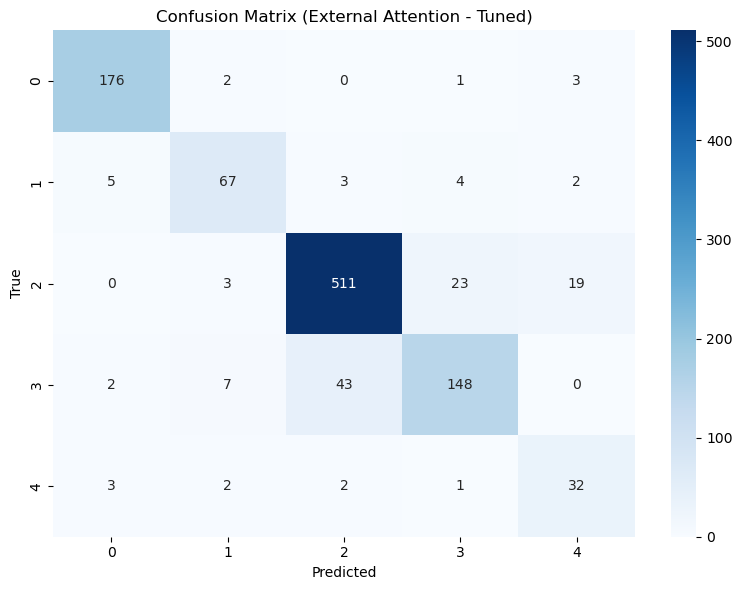

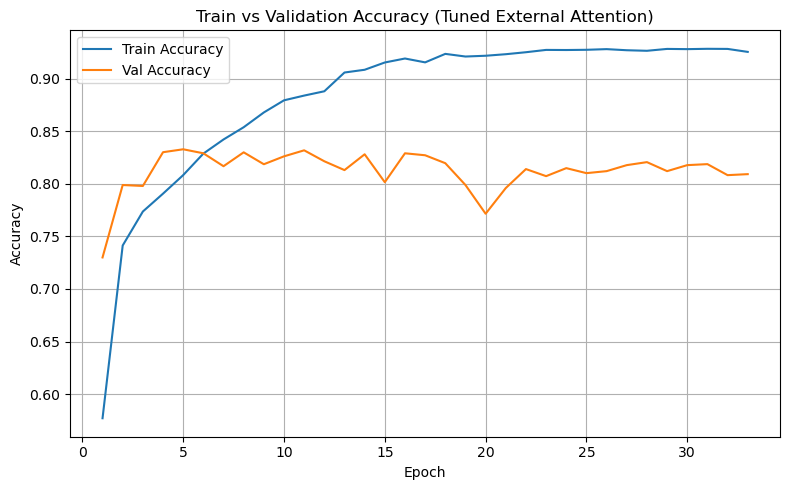

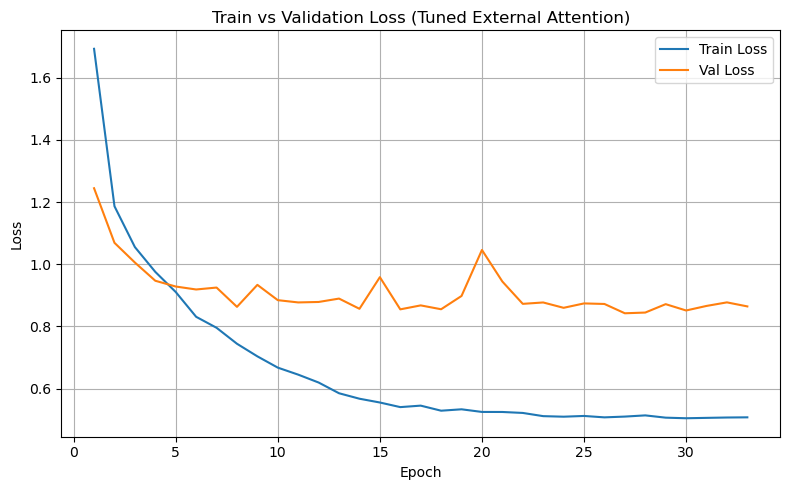

In [92]:
# Print final metrics
print("\n--- Final Performance (10-Fold CV, Tuned External Attention) ---")
for key in metrics:
    print(f"{key.capitalize()}: {np.mean(metrics[key]):.4f} ± {np.std(metrics[key]):.4f}")

# Confusion Matrix
cm = confusion_matrix(all_y_true, all_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (External Attention - Tuned)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Pad history lists to equal length
def pad_history(metric_name):
    max_len = max(len(h.history[metric_name]) for h in history_list)
    padded = []
    for h in history_list:
        vals = h.history[metric_name]
        if len(vals) < max_len:
            vals += [vals[-1]] * (max_len - len(vals))
        padded.append(vals)
    return np.array(padded)

# Plot averaged training curves
avg_train_acc = pad_history('accuracy').mean(axis=0)
avg_val_acc = pad_history('val_accuracy').mean(axis=0)
avg_train_loss = pad_history('loss').mean(axis=0)
avg_val_loss = pad_history('val_loss').mean(axis=0)
epochs = range(1, len(avg_train_acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, avg_train_acc, label='Train Accuracy')
plt.plot(epochs, avg_val_acc, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train vs Validation Accuracy (Tuned External Attention)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, avg_train_loss, label='Train Loss')
plt.plot(epochs, avg_val_loss, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss (Tuned External Attention)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
---